In [1]:
import numpy as np
from scipy.sparse.linalg import eigsh

from tqdm import tqdm 

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

from implicit.gpu import bpr, als
from implicit.evaluation import ranking_metrics_at_k
from scipy.sparse import csr_matrix

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from loaders import movielens, toy

In [2]:
SMALL_SIZE = 18
MEDIUM_SIZE = 24
BIGGER_SIZE = 24
plt.rc('font', size=SMALL_SIZE, family = "Nimbus Roman")          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
# plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

## Collaboration

In [3]:
def plot_relative_matrix(
    A,
    title="Matrix Visualization (Relative to Diagonal)",
    row_labels=None,
    col_labels=None,
    cmap_red='Reds',
    cmap_green='Greens',
    figsize=(8, 8)
):
    """
    Visualize a (possibly rectangular) matrix with off-"diagonal" coloring based on
    the difference from diagonal elements of each row, and optional row/column labels.

    For rows/columns where a true diagonal entry exists (i < min(n_rows, n_cols)),
    we compare each entry in that row to A[i, i]. For rows with no diagonal entry
    (i >= min(n_rows, n_cols)), we compare to 0.

    Parameters
    ----------
    A : np.ndarray
        2D matrix to visualize; need not be square.
    row_labels : list[str] or list[int], optional
        Labels for rows. Defaults to range(n_rows).
    col_labels : list[str] or list[int], optional
        Labels for columns. Defaults to range(n_cols).
    """

    A = np.asarray(A)
    assert A.ndim == 2, "Input must be a 2D matrix"
    n_rows, n_cols = A.shape

    # Default labels
    if row_labels is None:
        row_labels = list(range(n_rows))
    if col_labels is None:
        col_labels = list(range(n_cols))

    assert len(row_labels) == n_rows, "Row labels must match number of rows"
    assert len(col_labels) == n_cols, "Column labels must match number of columns"

    # Build row-wise "diagonal" reference:
    # For rows i < min(n_rows, n_cols), use A[i, i]; otherwise use 0 as baseline.
    diag_len = min(n_rows, n_cols)
    row_diag = np.zeros((n_rows, 1), dtype=A.dtype)
    diag_idx = np.arange(diag_len)
    row_diag[diag_idx, 0] = A[diag_idx, diag_idx]

    # Differences relative to row diagonal
    diff = A - row_diag

    # Normalize by max absolute off-diagonal difference
    off_diag_mask = np.ones_like(A, dtype=bool)
    off_diag_mask[diag_idx, diag_idx] = False  # mark true diagonal positions as not off-diagonal

#     if np.any(off_diag_mask):
#         max_diff = np.max(np.abs(diff[off_diag_mask]))
#     else:
#         max_diff = 0.0

#     if max_diff == 0:
#         max_diff = 1.0
    max_diff = 0.5
    norm = Normalize(vmin=0, vmax=max_diff)

    fig, ax = plt.subplots(figsize=figsize)

    # Background
    ax.imshow(np.zeros_like(A, dtype=float), cmap='gray', vmin=0, vmax=1)

    # Fill each cell manually
    for i in range(n_rows):
        for j in range(n_cols):
            # Check if this cell is on the "true" diagonal (i == j < diag_len)
            if i < diag_len and j == i:
                color = "white"
            else:
                d = diff[i, j]
                intensity = norm(abs(d))

                if d > 0:
                    color = plt.cm.get_cmap(cmap_green)(intensity)
                elif d < 0:
                    color = plt.cm.get_cmap(cmap_red)(intensity)
                else:
                    color = "white"

            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor=color))

            # Annotate numeric value
            ax.text(j, i, f"{A[i, j]:.2f}", ha="center", va="center", fontsize=12)

    # Tick settings
    ax.set_xticks(np.arange(n_cols))
    ax.set_yticks(np.arange(n_rows))
    ax.set_xticklabels(col_labels, rotation=45, ha='right')
    ax.set_yticklabels(row_labels)

    # Axes limits
    ax.set_xlim(-0.5, n_cols - 0.5)
    ax.set_ylim(n_rows - 0.5, -0.5)

    ax.set_aspect("equal")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


In [4]:

def get_train_test_X(X, p, seed=None):
    if not (0.0 <= p <= 1.0):
        raise ValueError(f"p must be in [0, 1], got {p}")

    X = np.asarray(X)
    rng = np.random.default_rng(seed)

    X_train = np.zeros_like(X)
    X_test = np.zeros_like(X)

    n_rows, n_cols = X.shape

    for i in range(n_rows):
        # Indices of non-zero entries in row i
        nz_cols = np.flatnonzero(X[i, :])

        # If the row is all zeros, skip
        if nz_cols.size == 0:
            continue

        # Number of non-zeros to put in train for this row
        n_train = int(np.round(p * nz_cols.size))

        # Randomly permute the non-zero column indices
        perm = rng.permutation(nz_cols)

        train_cols = perm[:n_train]
        test_cols = perm[n_train:]

        # Assign values
        X_train[i, train_cols] = X[i, train_cols]
        X_test[i, test_cols] = X[i, test_cols]

    return csr_matrix(X_train), csr_matrix(X_test)


Shape before filtering:  (6040, 3706)
Shape after filtering:  (6040, 1426)
1: 222
18: 1103
25: 2096
35: 1193
45: 550
50: 496
56: 380
2.0
28.33592715231788


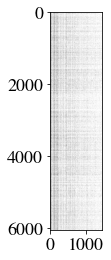

In [5]:
movielens_obj = movielens.movielens(
    min_ratings = 1,
    min_users = 200,
    binary=True, 
    data_dir="../data/")

label_to_idxs = movielens_obj.get_user_labels("Age")

# toy_obj = toy.Toy(item_block_size=500)
# label_to_idxs = toy_obj.get_user_labels()

for label, idxs in label_to_idxs.items():
    print(f"{label}: {len(idxs)}")
    
# create a 70/10/20 split
X = movielens_obj.get_X()
X_train, X_test = get_train_test_X(X, p=0.8)
X_train, X_val = get_train_test_X(X_train.toarray(), p=7/8)

assert np.sum(X > 0) == np.sum(X_train > 0) + np.sum(X_val > 0) + np.sum(X_test > 0)

plt.imshow(X, cmap="binary")

print(np.min(
    np.sum(X_test.toarray(), axis=1)
))
print(np.mean(
    np.sum(X_test.toarray(), axis=1)
))

100%|██████████| 11/11 [00:19<00:00,  1.76s/it]


[0.13626777003203838, 0.15618308566644665, 0.18166889379034984, 0.21573583629835943, 0.2344436752370679, 0.2409962487723987, 0.2244618678859498, 0.19427495049345547, 0.15412232543911902, 0.09951217941493729, 0.03851045674818476]


100%|██████████| 6/6 [00:01<00:00,  4.89it/s]


Text(0.5, 1.0, 'Precision@K')

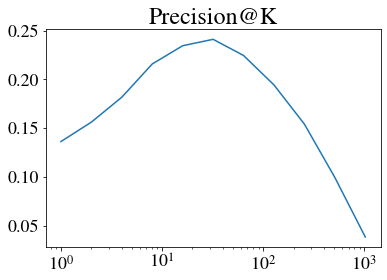

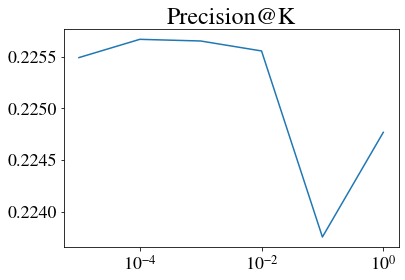

In [7]:
rs = [2**i for i in range(11)]
regs = [10**(-i) for i in range(6)]

precs = []
ndcgs = []
maps = []

for r in tqdm(rs):
#     ranking_model = bpr.BayesianPersonalizedRanking(factors=r, iterations=100)
    ranking_model = als.AlternatingLeastSquares(factors=r, iterations=100)

    ranking_model.fit(X_train, show_progress=False)
    
    ranking_metrics = ranking_metrics_at_k(ranking_model, X_train, X_val, K=20, show_progress=False)

    precs.append(ranking_metrics["precision"])
    ndcgs.append(ranking_metrics["ndcg"])
    maps.append(ranking_metrics["map"])
    
fig, ax = plt.subplots()
ax.plot(rs, precs)
ax.set_xscale("log")
ax.set_title("Precision@K")
print(precs)

precs = []

for reg in tqdm(regs):
#     ranking_model = bpr.BayesianPersonalizedRanking(factors=64, regularization=reg)
    ranking_model = als.AlternatingLeastSquares(factors=64, regularization=reg)

    ranking_model.fit(X_train, show_progress=False)
    
    ranking_metrics = ranking_metrics_at_k(ranking_model, X_train, X_val, K=20, show_progress=False)

    precs.append(ranking_metrics["precision"])
    ndcgs.append(ranking_metrics["ndcg"])
    maps.append(ranking_metrics["map"])
    
fig, ax = plt.subplots()
ax.plot(regs, precs)
ax.set_xscale("log")
ax.set_title("Precision@K")

# fig, ax = plt.subplots()
# ax.plot(rs, ndcgs)
# ax.set_title("NDCG@K")

# fig, ax = plt.subplots()
# ax.plot(rs, maps)
# ax.set_title("MAP@K")


In [104]:
# Group level performance on the full dataset

def group_level_performance(X_train, X_val, X_test, label_to_idxs, r=64):
    
    for label_i, idxs_i in label_to_idxs.items():
        reordered_idxs = idxs_i.copy()
        for label_j, idxs_j in label_to_idxs.items():
            if label_j == label_i:
                continue
            reordered_idxs.extend(idxs_j)

        bpr_model = bpr.BayesianPersonalizedRanking(factors=r, iterations=100)
        bpr_model.fit(X_train[reordered_idxs] + X_val[reordered_idxs], show_progress=False)

        ranking_metrics = ranking_metrics_at_k(bpr_model, 
                                               X_train[reordered_idxs] + X_val[reordered_idxs], 
                                               X_test[idxs_i], 
                                               K=20,
                                               show_progress=False)
        
        print(f"{label_i} \t\
        Prec: {round(ranking_metrics['precision'], 3)}\t\
        NDCG: {round(ranking_metrics['ndcg'], 3)}\t\
        MAP: {round(ranking_metrics['map'], 3)}\n")
        
group_level_performance(X_train, X_val, X_test, label_to_idxs, r=64)

1 	        Prec: 0.305	        NDCG: 0.275	        MAP: 0.136

18 	        Prec: 0.327	        NDCG: 0.314	        MAP: 0.161

25 	        Prec: 0.325	        NDCG: 0.312	        MAP: 0.159

35 	        Prec: 0.311	        NDCG: 0.298	        MAP: 0.149

45 	        Prec: 0.294	        NDCG: 0.268	        MAP: 0.13

50 	        Prec: 0.293	        NDCG: 0.268	        MAP: 0.128

56 	        Prec: 0.273	        NDCG: 0.25	        MAP: 0.117



In [102]:
labels = [label for label in label_to_idxs]
g = len(labels)
r = 64
reg = 0.01
num_trials = 1
rng = np.random.default_rng(seed=0)

group_by_group_prec = np.zeros((g, g + 1))
group_by_group_ndcg = np.zeros((g, g + 1))
group_by_group_map = np.zeros((g, g + 1))

n = X_train.shape[0]

for i, label_i in enumerate(labels):    
    for j in tqdm(range(g + 1)):
        
        precs, ndcgs, maps = [], [], []
        for _ in range(num_trials):
            train_row_idxs = label_to_idxs[label_i]
            if j != i:
                if j < g:
                    new_idxs = label_to_idxs[labels[j]]
                elif j == g:
                    new_idxs = []
                    for j_prime in range(g):
                        if j_prime != i:
                            new_idxs.extend(label_to_idxs[labels[j_prime]])
                            
                train_row_idxs = np.concatenate((
                    label_to_idxs[label_i],
#                     new_idxs,
                    rng.choice(
                        new_idxs, 
                        size = len(label_to_idxs[label_i]),
                        replace = True)
                ))

            X_train_subset = X_train[train_row_idxs]
            X_val_subset = X_val[train_row_idxs]
            X_test_subset = X_test[label_to_idxs[label_i]]

            bpr_model = bpr.BayesianPersonalizedRanking(factors=r,
                                                        regularization=reg,
                                                        iterations=100)
            bpr_model.fit(X_train_subset + X_val_subset, show_progress=False)
            
#             U = bpr_model.user_factors.to_numpy()
#             V = bpr_model.item_factors.to_numpy()
#             scores = 1/ (1 + np.exp(-U @ V.T))
            
#             fig, ax = plt.subplots()
#             ax.imshow(X_train_subset.toarray(), cmap="binary")
#             ax.set_title(f"{i,j}")
            
#             fig, ax = plt.subplots()
#             ax.imshow(scores, cmap="binary")
#             ax.set_title(f"{i,j}")
            
            ranking_metrics = ranking_metrics_at_k(bpr_model, 
                                                   X_train_subset + X_val_subset, 
                                                   X_test_subset, 
                                                   K=20,
                                                   show_progress=False)
            precs.append(ranking_metrics["precision"])
            ndcgs.append(ranking_metrics["ndcg"])
            maps.append(ranking_metrics["map"])
            
        group_by_group_prec[i, j] = np.mean(precs)
        group_by_group_ndcg[i, j] = np.mean(ndcgs)
        group_by_group_map[i, j] = np.mean(maps)


100%|██████████| 8/8 [00:01<00:00,  4.90it/s]


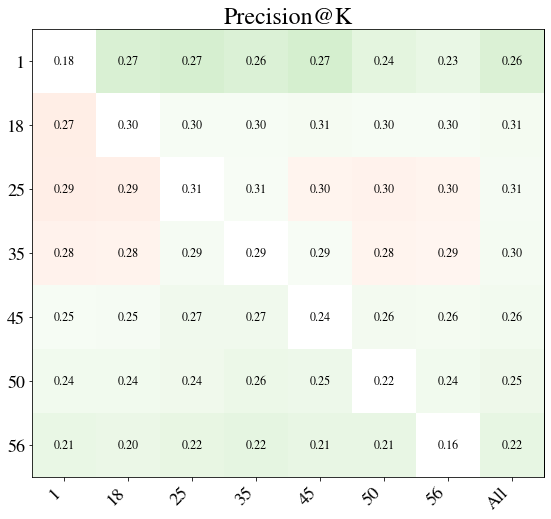

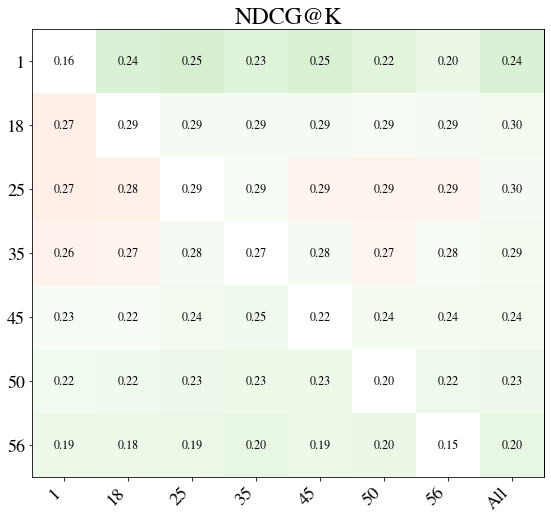

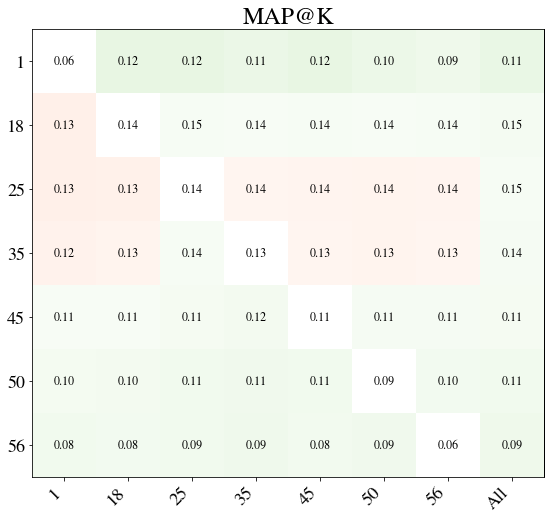

In [103]:
plot_relative_matrix(group_by_group_prec, 
                    row_labels=labels,
                    col_labels=labels + ["All"],
                    title="Precision@K")

plot_relative_matrix(group_by_group_ndcg, 
                    row_labels=labels,
                    col_labels=labels + ["All"],
                    title="NDCG@K")

plot_relative_matrix(group_by_group_map, 
                    row_labels=labels,
                    col_labels=labels + ["All"],
                    title="MAP@K")

## Data Mixing

In [122]:
def plot_density_with_baseline(values, baseline, value_name="Value", title="Density Plot"):
    """
    Pure Matplotlib density plot with a vertical dashed baseline line.
    """

    values = np.asarray(values)

    # Compute histogram-based density estimate
    density, bins = np.histogram(values, bins=50, density=True)
    centers = 0.5 * (bins[:-1] + bins[1:])

    plt.figure(figsize=(8, 5))

    plt.plot(centers, density, linewidth=2)
    plt.fill_between(centers, density, alpha=0.3)

    # Baseline line
    plt.axvline(baseline, color="red", linestyle="--", linewidth=2, label=f"Baseline = {round(baseline, 3)}")

    plt.title(title, fontsize=14)
    plt.xlabel(value_name)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()


100%|██████████| 500/500 [02:46<00:00,  3.00it/s]


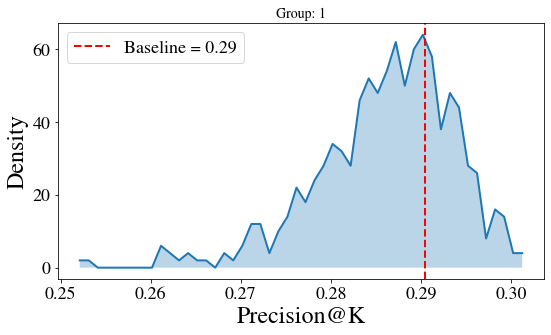

{'18': 0.8145771189119121, '25': 0.6263654881550328, '35': 0.6583197340133004, '45': 0.281775308128586, '50': 0.41557931655876656, '56': 0.8579195218559755}


100%|██████████| 500/500 [02:46<00:00,  3.01it/s]


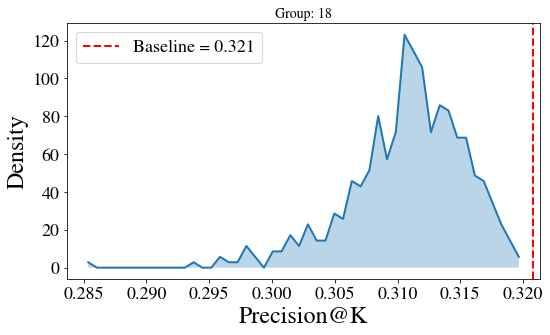

{'1': 222, '25': 2096, '35': 1193, '45': 550, '50': 496, '56': 380}


100%|██████████| 500/500 [02:55<00:00,  2.84it/s]


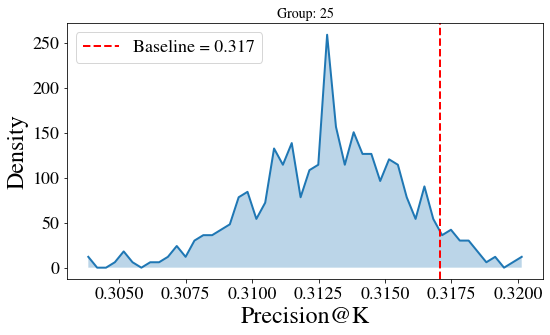

{'1': 0.1615090831197159, '18': 0.42178907061589177, '35': 0.32693467392304587, '45': 0.4059696951164735, '50': 0.2204560464954085, '56': 0.3730593156720282}


100%|██████████| 500/500 [02:46<00:00,  3.01it/s]


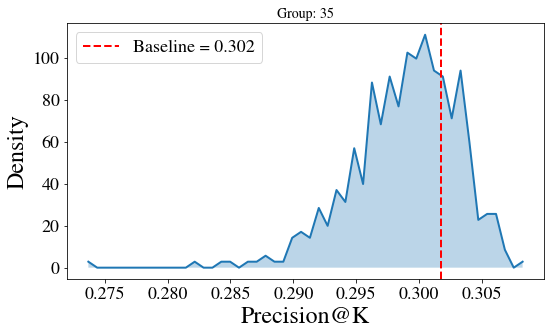

{'1': 0.09790721942300673, '18': 0.6492471816745892, '25': 0.7078724268863854, '45': 0.3935786952662198, '50': 0.7826187563273495, '56': 0.5128695274019108}


100%|██████████| 500/500 [02:43<00:00,  3.05it/s]


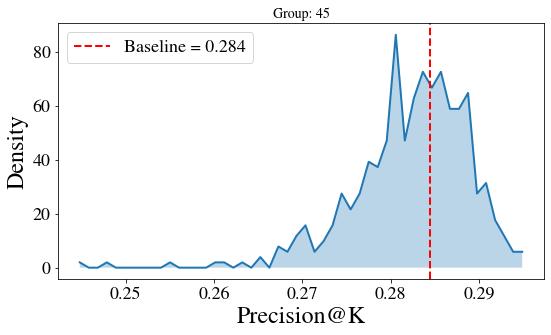

{'1': 0.2663213020735955, '18': 0.9577868650913869, '25': 0.6338410066581747, '35': 0.8968951458783992, '50': 0.28888967333604776, '56': 0.6860449766271989}


100%|██████████| 500/500 [02:44<00:00,  3.04it/s]


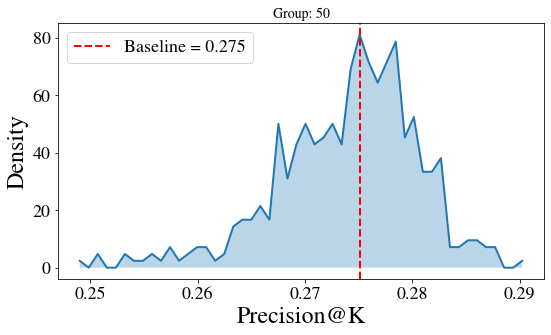

{'1': 0.2689332190890634, '18': 0.5567949492054641, '25': 0.6781966688769411, '35': 0.7402010150176912, '45': 0.6255371231023987, '56': 0.5193453963403918}


100%|██████████| 500/500 [02:47<00:00,  2.99it/s]


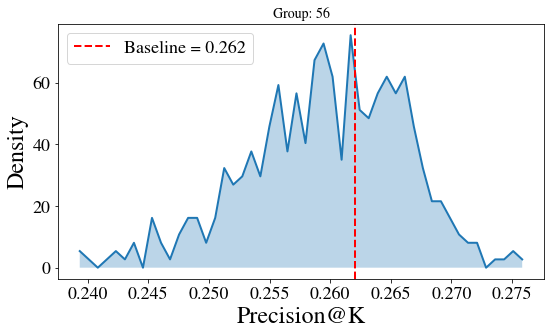

{'1': 0.39779464214190297, '18': 0.7098116327523903, '25': 0.8590187355838058, '35': 0.8448305888844052, '45': 0.6048153450920508, '50': 0.9040465884536643}


In [123]:
def random_data_mixing(X_train, X_val, X_test, label_to_idxs, r=64, trials=100):
    n = X_train.shape[0]
    rng = np.random.default_rng()
    
    for label_i, idxs_i in label_to_idxs.items():
        precs = []
        
        best_weights = {}
        group_weights = {label: len(idxs) for label, idxs in label_to_idxs.items() if label != label_i}
        total_weight =  np.sum(list(group_weights.values()))
        
        n_remaining = n - len(idxs_i)
        
        for _ in tqdm(range(trials)):
            reordered_idxs = idxs_i.copy()
            for label_j, idxs_j in label_to_idxs.items():
                if label_j == label_i:
                    continue
                    
                sample_size = int((group_weights[label_j] / total_weight) * n_remaining)
                
                reordered_idxs.extend(
                    rng.choice(idxs_j, size=sample_size, replace=True))

            bpr_model = bpr.BayesianPersonalizedRanking(factors=r, iterations=100)
            bpr_model.fit(X_train[reordered_idxs] + X_val[reordered_idxs], show_progress=False)

            ranking_metrics = ranking_metrics_at_k(bpr_model, 
                                                   X_train[reordered_idxs] + X_val[reordered_idxs], 
                                                   X_test[idxs_i], 
                                                   K=20,
                                                   show_progress=False)
            prec = ranking_metrics["precision"]
            if len(precs) == 0 or prec > np.max(precs):
                best_weights = group_weights.copy()
            precs.append(prec)
            
            group_weights = {label: rng.random() for label in label_to_idxs if label != label_i}
            total_weight =  np.sum(list(group_weights.values()))
            
        plot_density_with_baseline(precs[1:], 
                                   baseline=precs[0], 
                                   value_name="Precision@K", 
                                   title=f"Group: {label_i}")
        print(best_weights)
        
random_data_mixing(X_train, X_val, X_test, label_to_idxs, r=64, trials=1000)

In [126]:
group_weights = {'1': 0.2689332190890634, '18': 0.5567949492054641, '25': 0.6781966688769411, '35': 0.7402010150176912, '45': 0.6255371231023987, '56': 0.5193453963403918}
total_weight = np.sum(list(group_weights.values()))

for group in group_weights:
    print(f"{group}: {group_weights[group] / total_weight}")

1: 0.07935454551844637
18: 0.16429435638642104
25: 0.20011655165972952
35: 0.21841227103881516
45: 0.184578217138241
56: 0.15324405825834683
